First, we'll install the `kaggle` library, which allows us to interact with the Kaggle API.

In [ ]:
pip install kaggle

Next, we'll set up your Kaggle API credentials as environment variables. Please replace `YOUR_KAGGLE_USERNAME` with your actual Kaggle username.

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'ashlinjohnj'
os.environ['KAGGLE_KEY'] = '839c959018a0ec05d364c96c7a85cca1'

!mkdir -p ~/.kaggle
!echo '{"username":"'${os.environ['KAGGLE_USERNAME']}'","key":"'${os.environ['KAGGLE_KEY']}'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

/bin/bash: line 1: '{"username":"'${os.environ['KAGGLE_USERNAME']}'","key":"'${os.environ['KAGGLE_KEY']}'"}': bad substitution
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Now, we'll download the specified dataset from Kaggle.

In [ ]:
!kaggle datasets download -d orchit/the-fabrics-dataset-by-ibug

Dataset URL: https://www.kaggle.com/datasets/orchit/the-fabrics-dataset-by-ibug
License(s): unknown
100% 1.77G/1.77G [02:09<00:00, 14.7MB/s]



Finally, we'll unzip the downloaded dataset.

In [ ]:
!unzip the-fabrics-dataset-by-ibug.zip -d the-fabrics-dataset

Streaming output truncated to the last 5000 lines.
  inflating: the-fabrics-dataset/Cotton/50/im_4.png  
  inflating: the-fabrics-dataset/Cotton/50/tag.txt  
  inflating: the-fabrics-dataset/Cotton/507/im_1.png  
  inflating: the-fabrics-dataset/Cotton/507/im_2.png  
  inflating: the-fabrics-dataset/Cotton/507/im_3.png  
  inflating: the-fabrics-dataset/Cotton/507/im_4.png  
  inflating: the-fabrics-dataset/Cotton/507/tag.txt  
  inflating: the-fabrics-dataset/Cotton/508/im_1.png  
  inflating: the-fabrics-dataset/Cotton/508/im_2.png  
  inflating: the-fabrics-dataset/Cotton/508/im_3.png  
  inflating: the-fabrics-dataset/Cotton/508/im_4.png  
  inflating: the-fabrics-dataset/Cotton/508/tag.txt  
  inflating: the-fabrics-dataset/Cotton/51/im_1.png  
  inflating: the-fabrics-dataset/Cotton/51/im_2.png  
  inflating: the-fabrics-dataset/Cotton/51/im_3.png  
  inflating: the-fabrics-dataset/Cotton/51/im_4.png  
  inflating: the-fabrics-dataset/Cotton/51/tag.txt  
  inflating: the-fabrics-

## Build a Fabric Classification Model

First, we'll import the necessary libraries and set up the path to our dataset.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

dataset_dir = 'the-fabrics-dataset'

if not os.path.exists(dataset_dir):
    print(f"Error: Dataset directory '{dataset_dir}' not found.")
else:
    print(f"Dataset directory '{dataset_dir}' found.")

Dataset directory 'the-fabrics-dataset' found.


Next, we'll load the image data using `image_dataset_from_directory`. This utility automatically infers class labels from the directory structure and creates a `tf.data.Dataset` object, which is optimized for training. We'll also split the dataset into training, validation, and test sets.

Found 7885 files belonging to 25 classes.
Using 6308 files for training.
Found 7885 files belonging to 25 classes.
Using 1577 files for validation.
Class names: ['Acrylic', 'Artificial_fur', 'Artificial_leather', 'Blended', 'Chenille', 'Corduroy', 'Cotton', 'Crepe', 'Denim', 'Felt', 'Fleece', 'Leather', 'Linen', 'Lut', 'Nylon', 'Polyester', 'Satin', 'Silk', 'Suede', 'Terrycloth', 'Unclassified', 'Utilities', 'Velvet', 'Viscose', 'Wool']
Number of classes: 25


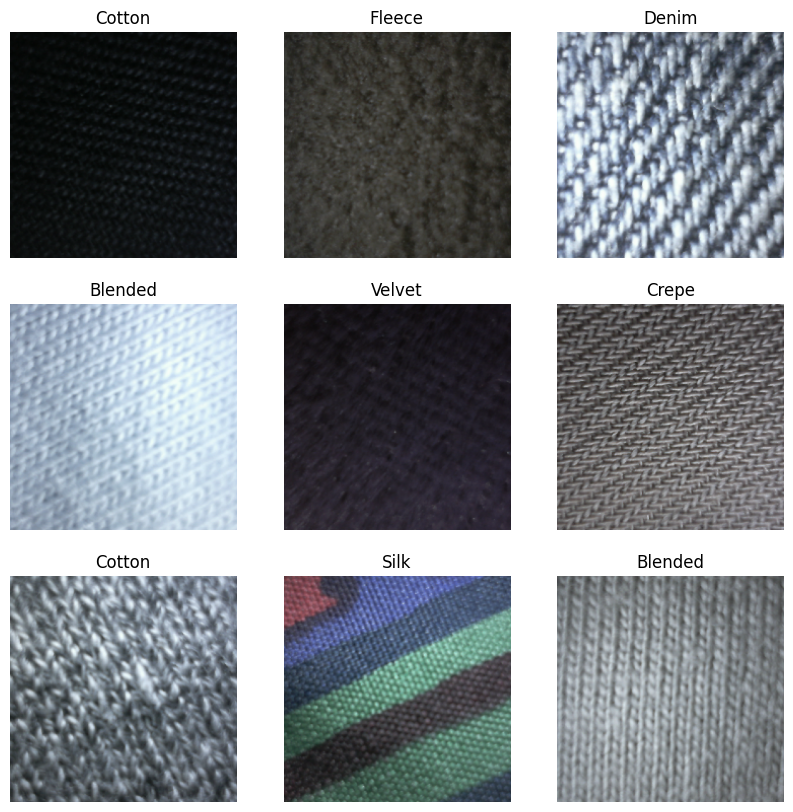

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

To improve performance, we'll apply caching and prefetching to our datasets.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Now, we will define a simple Convolutional Neural Network (CNN) architecture. This model will take the preprocessed images as input and output probabilities for each fabric class.

In [ ]:
num_classes = len(class_names)

model = keras.Sequential([
  layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  layers.Conv2D(32, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(256, activation='relu'),
  layers.Dense(num_classes)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,251,097 (84.88 MB)

 Trainable params: 22,251,097 (84.88 MB)

 Non-trainable params: 0 (0.00 B)

Now, we'll compile the model, specifying the optimizer, loss function, and metrics. Then, we'll train the model using our training and validation datasets.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
dataset_dir = 'the-fabrics-dataset'

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)

model = keras.Sequential([
  layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  layers.Conv2D(32, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(256, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Found 7885 files belonging to 25 classes.
Using 6308 files for training.
Found 7885 files belonging to 25 classes.
Using 1577 files for validation.
Epoch 1/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 49s 204ms/step - accuracy: 0.2925 - loss: 2.3014 - val_accuracy: 0.3748 - val_loss: 2.0802
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.3678 - loss: 1.9910 - val_accuracy: 0.3824 - val_loss: 1.9607
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.4228 - loss: 1.7651 - val_accuracy: 0.4192 - val_loss: 1.8328
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 34s 169ms/step - accuracy: 0.5165 - loss: 1.4571 - val_accuracy: 0.5003 - val_loss: 1.5624
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 45s 190ms/step - accuracy: 0.6417 - loss: 1.0769 - val_accuracy: 0.5054 - val_loss: 1.6325
Epoch 6/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.7792 - loss: 0.6707 - val_accuracy: 0.5504 - val_loss: 1.6746
Epoch 7/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save("/content/drive/MyDrive/pr/fabric_model.keras")

In [ ]:
from tensorflow import keras

model = keras.models.load_model("/content/drive/MyDrive/pr/fabric_model.keras")

Let's visualize the training and validation accuracy and loss over epochs to see how our model performed.

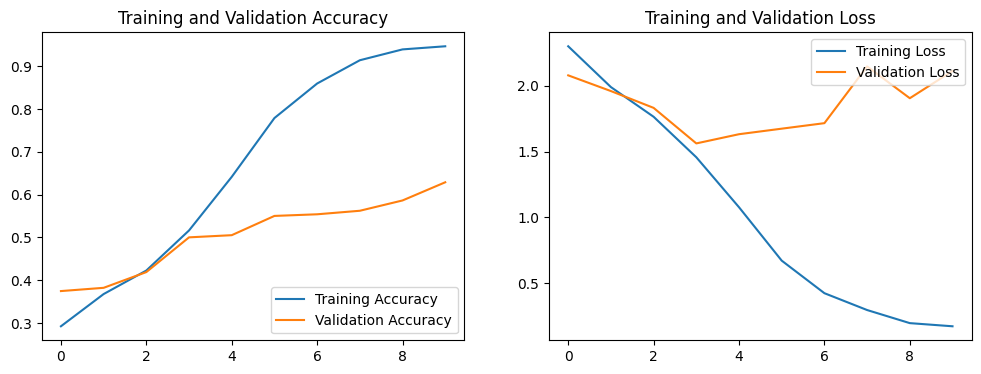

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Finally, we'll create a function to classify a single input image. This function will preprocess the image and use the trained model to predict its fabric type.

In [ ]:
import cv2

def classify_image(image_path):
    img = tf.keras.utils.load_img(
        image_path, target_size=(IMG_HEIGHT, IMG_WIDTH)
    )
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    print(
        "This image most likely belongs to {} with a {:.2f} percent confidence."
        .format(class_names[np.argmax(score)], 100 * np.max(score))
    )
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[np.argmax(score)]} ({100 * np.max(score):.2f}%) ")
    plt.axis('off')
    plt.show()

Select your fabric image to upload:


Saving image-25-1024x682.webp to image-25-1024x682 (5).webp
Processing uploaded file: image-25-1024x682 (5).webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
This image most likely belongs to Corduroy with a 57.24 percent confidence.


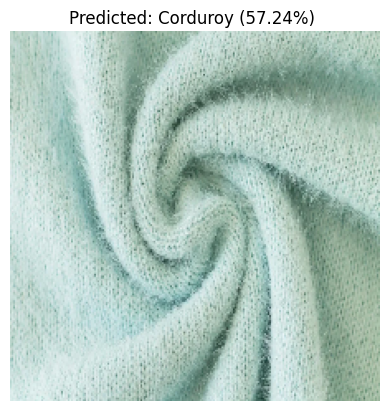

In [ ]:
from google.colab import files
import os

print("Select your fabric image to upload:")
uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f"Processing uploaded file: {filename}")
        classify_image(filename)
else:
    print("No file was selected.")

The dataset should now be available in the `the-fabrics-dataset` directory.